# Week 6 Day 4: LangGraph Integration — Routing Between Chat, Retrieval & Prediction

### Goal
Today we'll be connecting everything built so far into one LangGraph app:
- Day 2's prediction models (match winner, top player by stat)
- Day 3's retrieval tools and AFL-only chat agent

The app needs to figure out what kind of question it got (factual, retrieval, prediction, or off-topic) and route it to the right place, instead of relying on one agent to freely decide everything

Reusing as is from before:
- `team_match_features_v1_2026-07-27.csv`, `player_match_features_v1_2026-07-27.csv`
- `models/` folder (match_winner_model, top_player models, latest_team_features, latest_player_features, valid_teams)
- `predict.py` functions and the retrieval tools + system prompt from `afl_chat_agent.py`

## Loading and Setup

In [6]:
pip install scikit-learn

  Obtaining dependency information for scikit-learn from https://files.pythonhosted.org/packages/3b/67/be3d369f40d8178ba3bd86635d132e08cb5329b023e4669d9426d84bc007/scikit_learn-1.9.0-cp311-cp311-win_amd64.whl.metadata
  Using cached scikit_learn-1.9.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Obtaining dependency information for scipy>=1.10.0 from https://files.pythonhosted.org/packages/95/da/0d1df507cf574b3f224ccc3d45244c9a1d732c81dcb26b1e8a766ae271a8/scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Obtaining dependency information for narwhals>=2.0.1 from https://files.pythonhosted.org/packages/7e/85/a5bfaebfd305ac18b57b0854d74e37e586809061a91fda62f0bd50c8518e/narwhals-2.24.0-py3-none-any.whl.metadata
  Obtaining dependency information for threadpoolctl>=3.5.0 from https://files.pythonhosted.org/packages/32/d5/f9a850d79b0851d1d4ef6456097579a9005b31fea68726a4ae5f2d82ddd9/threadpoolctl-3.6.0-py3-none-any.whl.met


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: C:\Users\imama\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [1]:
pip install langgraph langchain langchain-openai pandas joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: C:\Users\imama\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [20]:
import pandas as pd
import numpy as np
import joblib
import json
import os

from dotenv import load_dotenv

load_dotenv()
pd.set_option('display.max_columns', None)

team = pd.read_csv('team_match_features_v1_2026-07-27.csv')
player = pd.read_csv('player_match_features_v1_2026-07-27.csv')

print("team rows:", len(team), "| player rows:", len(player))

team rows: 15808 | player rows: 274089


In [2]:
ARTIFACT_DIR = "models"

_match_model = joblib.load(f"{ARTIFACT_DIR}/match_winner_model.joblib")
_player_models ={
    "disposals": joblib.load(f"{ARTIFACT_DIR}/top_player_model_disposals.joblib"),
    "goals": joblib.load(f"{ARTIFACT_DIR}/top_player_model_goals.joblib"),
    "fantasy_points": joblib.load(f"{ARTIFACT_DIR}/top_player_model_fantasy_points.joblib"),
}
_latest_team_features = joblib.load(f"{ARTIFACT_DIR}/latest_team_features.joblib")
_latest_player_features = joblib.load(f"{ARTIFACT_DIR}/latest_player_features.joblib")
_valid_teams = joblib.load(f"{ARTIFACT_DIR}/valid_teams.joblib")

print(f"{len(_valid_teams)} valid teams loaded")
print(f"models loaded: match winner + 3 top player models (disposals, goals, fantasy_points)")

20 valid teams loaded
models loaded: match winner + 3 top player models (disposals, goals, fantasy_points)


In [175]:
# MODEL = "smart"

# from langchain_openai import ChatOpenAI

# llm = ChatOpenAI(
#     model=MODEL,
#     base_url=os.environ["BASE_URL"],
#     api_key=os.environ["API_KEY"],
# )

## Task 1: Graph Design for the Full System

### State schema

The state needs to carry the user's question all the way through the graph, plus whatever each node adds along the way:

* `user_query`: the user's question.
* `conversation_history`: previous messages, so the agent remembers earlier parts of the conversation.
* `intent`: what the user is trying to do (intent classification) (`factual`, `retrieval`, `prediction`, or `off_topic`).
* `entities`: important information found in the question, like team names, player names, or the stat type.
* `tool_result`: the result returned by the retrieval or prediction tool.
* `error`: stores any error if something goes wrong (for example, if a team or player isn't found).
* `needs_clarification`: tells the graph if it should ask the user for more information instead of guessing.
* `clarification_question`: the question shown to the user when more information is needed.
* `final_response`: the final answer sent back to the user.
* `trace`: a log of what each node did, so it's easier to debug and see how the graph reached its answer.


### Graph sketch

```
                            user_query
                                 |
                                 |
                                 |
                                 ↓
                        +----------------+
                        |   router node   |
                        | (intent + entity|
                        |  extraction)    |
                        +--------+-------+
                                 |
           +---------------------+----------------------+---------------------+
           |                     |                       |                    |
     intent=retrieval     intent=prediction       intent=factual       intent=off_topic
           |                     |                       |                    |
   +-------v------+     +--------v-------+                |                    |
   | retrieval    |     | prediction     |                |                    |
   | node (stats, |     | node (match /  |                |                    |
   | head-to-head)|     | top player)    |                |                    |
   +-------+------+     +--------+-------+                |                    |
           |                     |                        |                    |
           +----------+----------+                        |                    |
                      |                                    |                    |
              +-------v--------+                           |                    |
              | validation node |                          |                    |
              | (did the tool   |                          |                    |
              |  actually work?)|                          |                    |
              +-------+--------+                           |                    |
                      |                                    |                    |
           needs_clarification? ---yes--> (ask user)        |                    |
                      | no                                  |                    |
                      +-----------------+--------------------+--------------------+
                                        |
                              +---------v----------+
                              | response formatting |
                              | node (adds          |
                              | probability wording |
                              | for predictions)     |
                              +---------+-----------+
                                        |
                                     final_response
```


| **Component**                | **Explanation**                                                                          |
| ---------------------------- | ---------------------------------------------------------------------------------------- |
| **user_query**               | The user's question enters the graph here.                                               |
| **router node**              | Figures out what the user wants and extracts things like team or player names.           |
| **intent = retrieval**       | Used when the user is asking for existing AFL stats or records.                          |
| **retrieval node**           | Looks up the requested information from the dataset.                                     |
| **intent = prediction**      | Used when the user is asking the model to make a prediction.                             |
| **prediction node**          | Calls the prediction models to generate match or player predictions.                     |
| **intent = factual**         | Used for general AFL questions that don't need a tool.                                   |
| **intent = off_topic**       | Used when the question isn't related to AFL.                                             |
| **validation node**          | Checks whether the retrieval or prediction tool returned a valid result.                 |
| **needs_clarification?**     | If something is missing or unclear, the graph asks the user instead of guessing.         |
| **response formatting node** | Formats the final answer and adds probabilities/disclaimers for predictions when needed. |
| **final_response**           | The final answer that gets sent back to the user.                                        |

### Justification: Why use explicit routing instead of one free agent?

A single agent decides on its own what to do, every time the user asks something. It chooses which tool to use and how to answer. While this is flexible, it also means it might forget important rules.

For example, prediction answers are supposed to sound like probabilities instead of certainties, but the agent could accidentally ignore that and make a prediction sound guaranteed.

Using LangGraph makes the process much more controlled. Every prediction always follows the same path: 

**prediction_node --> validation_node --> response_formatting_node**. 

This means every prediction is checked first, then the response is automatically formatted with a probability and a disclaimer before it's shown to the user. 

Retrieval results also go through validation, so if a team or player can't be found, the graph asks the user for clarification instead of guessing. This makes the system more reliable, consistent, and much easier to debug

## Task 2: Building the Router Node

I chose a lightweight **rule-based classifier** instead of using an LLM to classify the intent.

The router only needs to decide between four categories (prediction, retrieval, factual, and off_topic), which can be identified reliably using simple keywords and phrases. Using an LLM for such a small task would add unnecessary API calls, increase response time, and make the routing less consistent since LLM outputs can vary slightly.

A rule-based classifier is:

Fast since it runs locally with no API call.
Deterministic, so the same question always gets the same route.
Easy to test and debug when checking routing accuracy.
Simple to extend by adding new keywords if more intents are needed later.

If the application became more complex or users started asking much more varied questions, the router could later be replaced with an LLM-based classifier. However, for the four intents required in this task, a lightweight classifier is sufficient and keeps the routing process efficient.

### Intent Classifier (router)

#### Making the Cues


In [14]:
PREDICTION_CUES = [
    "will win","who will win","who's going to win","who is going to win","predict",
    "winner","will beat","beat","top score","top-score","who will top score",
    "who will top-score","most disposals this week","highest fantasy this week","who will get the most",
    "gonna win","going to beat","chances of","win probability","more likely to win",
    "likely to win",
]
RETRIEVAL_CUES = [
    "recent stats", "stats", "statistics", "record against", "head to head",
    "h2h", "last round", "recent form", "average", "how many disposals",
    "how many goals", "fantasy points", "results", "last season", "record",
]
OFFTOPIC_CUES = [
    "nrl", "nba", "soccer", "cricket", "weather", "pizza", "recipe", "python",
    "capital of", "joke", "world cup", "super bowl", "fifa", "stock market",
    "movie", "song",
]

In [124]:
# small set of team nicknames, used only so the router can tell a query is AFL-related
# even if it doesn't hit a prediction/retrieval keyword. Full alias -> exact team name
_AFL_NICKNAME_WORDS = [
    "pies", "collingwood", "cats", "geelong", "tigers", "richmond", "blues", "carlton",
    "dees", "melbourne", "swans", "sydney", "hawks", "hawthorn", "lions", "brisbane",
    "bombers", "essendon", "saints", "st kilda", "eagles", "dogs", "bulldogs", "power",
    "suns", "giants", "gws", "dockers", "freo", "fremantle", "roos", "kangaroos", "crows",
    "adelaide",
]

_known_players_lower = {p.lower(): p for p in player["player_name"].dropna().unique()}

def mentions_known_player(query):
    ql = query.lower()
    return any(p in ql for p in _known_players_lower)

def contains_afl_context(query):
    """True if the query mentions AFL, a valid team name, a common nickname, or a known player."""
    ql = query.lower()
    if "afl" in ql:
        return True
    if any(t.lower() in ql for t in _valid_teams):
        return True
    if any(w in ql for w in _AFL_NICKNAME_WORDS):
        return True
    if mentions_known_player(query):
        return True
    return False


#### Classify Function

In [125]:
def classify_intent(query):
    """
    Classifies a user's question into one of four intents:
    prediction, retrieval, factual, or off_topic.
    """

    query = query.lower()

    has_prediction = any(word in query for word in PREDICTION_CUES)
    has_retrieval = any(word in query for word in RETRIEVAL_CUES)
    has_offtopic = any(word in query for word in OFFTOPIC_CUES)

    # off_topic only wins if there's no prediction/retrieval signal too
    # (a query can mention "weather" style words but still clearly be AFL related)
    if has_offtopic and not has_prediction and not has_retrieval:
        return "off_topic"

    if has_prediction:
        return "prediction"

    if has_retrieval:
        return "retrieval"

    # nothing matched: only call it factual if it actually mentions AFL,
    # a team, or a player, otherwise it's off_topic by default
    if contains_afl_context(query):
        return "factual"

    return "off_topic"

### Test Queries

In [126]:
test_queries = [
    ("Who will win Richmond Tigers vs Carlton Blues?", "prediction"),
    ("Will Collingwood beat Geelong?", "prediction"),
    ("Who will top score for Brisbane Lions?", "prediction"),
    ("Predict the winner of Sydney Swans vs Hawthorn.", "prediction"),

    ("Show me Patrick Cripps' recent stats.", "retrieval"),
    ("What were Nick Daicos' stats last round?", "retrieval"),
    ("What's Carlton's record against Richmond?", "retrieval"),
    ("How many disposals does Patrick Cripps average?", "retrieval"),

    ("Tell me about the Richmond Tigers.", "factual"),
    ("How many teams are in the AFL?", "factual"),
    ("Explain the AFL finals system.", "factual"),
    ("When was the AFL founded?", "factual"),

    ("What's today's weather?", "off_topic"),
    ("Tell me a joke.", "off_topic"),
    ("Write me a Python program.", "off_topic"),
    ("Who won the FIFA World Cup?", "off_topic"),
    ("Recommend a pizza place.", "off_topic"),
    ("What's the capital of France?", "off_topic"),
    ("Who won the Super Bowl?", "off_topic"),
    ("What's the stock market doing today?", "off_topic"),
]

### Accuracy Table

In [127]:
results = []

for query, expected in test_queries:

    predicted = classify_intent(query)

    results.append({
        "Query": query,
        "Expected": expected,
        "Predicted": predicted,
        "Result": "PASS" if expected == predicted else "FAIL"
    })

routing_results = pd.DataFrame(results)

routing_results

,Query,Expected,Predicted,Result
0,Who will win Richmond Tigers vs Carlton Blues?,prediction,prediction,PASS
1,Will Collingwood beat Geelong?,prediction,prediction,PASS
2,Who will top score for Brisbane Lions?,prediction,prediction,PASS
3,Predict the winner of Sydney Swans vs Hawthorn.,prediction,prediction,PASS
4,Show me Patrick Cripps' recent stats.,retrieval,retrieval,PASS
5,What were Nick Daicos' stats last round?,retrieval,retrieval,PASS
6,What's Carlton's record against Richmond?,retrieval,retrieval,PASS
7,How many disposals does Patrick Cripps average?,retrieval,retrieval,PASS
8,Tell me about the Richmond Tigers.,factual,factual,PASS
9,How many teams are in the AFL?,factual,factual,PASS


### Overall Accuracy

In [128]:
accuracy = (routing_results["Result"] == "PASS").mean() * 100

print(f"Routing Accuracy: {accuracy:.1f}%")

Routing Accuracy: 100.0%


### Checking Misroutes

In [13]:
routing_results[routing_results["Result"] == "FAIL"]

,Query,Expected,Predicted,Result
1,Will Collingwood beat Geelong?,prediction,factual,FAIL


Leaving the above cell as is to show the misrouting

**Observation:** During the initial testing, one prediction query ("Will Collingwood beat Geelong?") was incorrectly classified as a factual question. The router relied on exact keyword phrases such as "will beat", which did not match because the team name appeared between "will" and "beat". To fix this, the prediction keyword list was expanded by adding the more general keyword "beat", allowing the router to correctly identify similar prediction questions. After refining the keyword list, the router correctly classified all 20 test queries.

**Before:** 
``` 
PREDICTION_CUES = [
    "will win", "who will win", "who's going to win", "who is going to win",
    "predict", "who will beat", "will beat", "top score", "top-score",
    "who will top score", "who will top-score", "most disposals this week",
    "highest fantasy this week", "who will get the most", "beat the", "gonna win",
    "going to beat", "chances of", "win probability", "more likely to win", "likely to win",
]
```

Routing Accuracy: 95.0%


**After:**
```
PREDICTION_CUES = [
    "will win","who will win","who's going to win","who is going to win","predict",
    "winner","will beat","beat","top score","top-score","who will top score",
    "who will top-score","most disposals this week","highest fantasy this week","who will get the most",
    "gonna win","going to beat","chances of","win probability","more likely to win",
    "likely to win",
]
```
Routing Accuracy: 100.0%


In [129]:
routing_results[routing_results["Result"] == "FAIL"]

,Query,Expected,Predicted,Result


In [207]:
routing_results.to_csv("routing_accuracy_results.csv")

## Task 3: Wire Prediction Models as LangGraph Tools

### Importinb prediction functions



In [105]:
from predict import predict_match_winner, predict_top_player
from predict import _match_model, _player_models, _MATCH_NUM_FEATS, _PLAYER_FEATS
from langchain.tools import tool
import difflib

### Team nickname resolution

We only need this now because prediction tools require the exact team names

In [176]:
TEAM_ALIASES = {
    "pies": "Collingwood Magpies",
    "collingwood": "Collingwood Magpies",

    "cats": "Geelong Cats",
    "geelong": "Geelong Cats",

    "tigers": "Richmond Tigers",
    "richmond": "Richmond Tigers",

    "blues": "Carlton Blues",
    "carlton": "Carlton Blues",

    "dees": "Melbourne Demons",
    "melbourne": "Melbourne Demons",

    "swans": "Sydney Swans",
    "sydney": "Sydney Swans",

    "hawks": "Hawthorn Hawks",
    "hawthorn": "Hawthorn Hawks",

    "lions": "Brisbane Lions",
    "brisbane": "Brisbane Lions",

    "bombers": "Essendon Bombers",
    "essendon": "Essendon Bombers",

    "dogs": "Western Bulldogs",
    "bulldogs": "Western Bulldogs",

    "dockers": "Fremantle Dockers",
    "freo": "Fremantle Dockers",

    "crows": "Adelaide Crows",
    "adelaide": "Adelaide Crows",

    "power": "Port Adelaide Power",
    "port adelaide": "Port Adelaide Power",

    "giants": "Greater Western Sydney Giants",
    "gws": "Greater Western Sydney Giants",

    "roos": "North Melbourne Kangaroos",
    "kangaroos": "North Melbourne Kangaroos",

    "eagles": "West Coast Eagles",

    "saints": "St Kilda Saints",
    "st kilda": "St Kilda Saints",

    "suns": "Gold Coast Suns"
}

In [177]:
def resolve_team(team_name):
    """
    Resolves a team nickname to the exact team name used by the prediction models.
    """

    if not team_name:
        return None

    name = team_name.lower().strip()

    if name in TEAM_ALIASES:
        return TEAM_ALIASES[name]

    matches = difflib.get_close_matches(
        team_name,
        _valid_teams,
        n=1,
        cutoff=0.6
    )

    if matches:
        return matches[0]

    return None

### Upcoming fixture placeholder
The task mentions resolve "this week" to the correct fixture/date.

since I dont have a live fixture API, im using the latest available team features that I contained in a joblib on Day 2

In [178]:
def resolve_fixture(home_team, away_team):
    """
    Resolves the requested fixture.

    This project does not use a live AFL fixture API,
    so predictions use the latest available feature table
    as the current week's matchup.
    """

    return {
        "home_team": home_team,
        "away_team": away_team,
        "fixture": "latest available matchup"
    }

### Tools

### 1. Match prediction tool

In [179]:
# real top-3 feature grounding, computed from the models directly (not just a
# static description). Match model is logistic regression, so we can read off
# each feature's contribution to this specific prediction. Player models are
# gradient boosting, so we use the model's overall top feature importances instead
# (per-instance contribution isn't as simple to read off a tree ensemble without SHAP).

def top_match_features(X_df):
    pre = _match_model.named_steps["pre"]
    clf = _match_model.named_steps["clf"]
    X_trans = pre.transform(X_df)
    coefs = clf.coef_[0]
    contributions = X_trans[0] * coefs
    idx_sorted = sorted(range(len(_MATCH_NUM_FEATS)), key=lambda i: -abs(contributions[i]))[:3]
    out = []
    for i in idx_sorted:
        direction = "favors the home team" if contributions[i] > 0 else "favors the away team"
        out.append(f"{_MATCH_NUM_FEATS[i]} ({direction})")
    return out

def top_player_features(stat_type):
    reg = _player_models[stat_type].named_steps["reg"]
    importances = reg.feature_importances_
    idx_sorted = sorted(range(len(_PLAYER_FEATS)), key=lambda i: -importances[i])[:3]
    return [_PLAYER_FEATS[i] for i in idx_sorted]


In [180]:
@tool
def match_prediction_tool(home_team: str, away_team: str):
    """
    Predict the winner of an AFL match.
    """

    home = resolve_team(home_team)
    away = resolve_team(away_team)

    if home is None or away is None:
        return "One or both team names could not be recognised."

    fixture = resolve_fixture(home, away)

    prediction = predict_match_winner(
        fixture["home_team"],
        fixture["away_team"]
    )

    # build the same feature row predict_match_winner used internally, so we can
    # explain this specific prediction rather than just describing the model in general
    home_row = _latest_team_features[_latest_team_features["team_name"] == home].iloc[0]
    away_row = _latest_team_features[_latest_team_features["team_name"] == away].iloc[0]
    feat_cols = ["recent_form_5", "avg_score_last5", "win_streak_entering_match", "days_rest",
                 "points_before_match", "ladder_position_before_match",
                 "h2h_win_rate_vs_opponent", "venue_win_rate"]
    row = {}
    for c in feat_cols:
        row[f"home_{c}"] = home_row[c]
        row[f"away_{c}"] = away_row[c]
    X = pd.DataFrame([row])[_MATCH_NUM_FEATS]

    prediction["top_features"] = top_match_features(X)
    prediction["grounding"] = (
        "Prediction uses each team's recent form (last 5 matches), "
        "ladder position before the match, "
        "and average scoring performance. "
        "Top drivers for this matchup: " + "; ".join(prediction["top_features"]) + "."
    )

    return prediction

#### 2. Top Player Tool

In [181]:
@tool
def top_player_prediction_tool(
    team: str,
    stat_type: str = "disposals"
):
    """
    Predict the top player for an AFL team.
    """

    team = resolve_team(team)

    if team is None:
        return "Team not recognised."

    if stat_type not in _player_models:
        return f"'{stat_type}' isn't a stat this system predicts. Supported: {list(_player_models.keys())}."

    prediction = predict_top_player(
        team,
        stat_type=stat_type,
        top_n=5
    )

    top_feats = top_player_features(stat_type)

    return {
        "team": team,
        "stat_type": stat_type,
        "prediction": prediction,
        "top_features": top_feats,
        "grounding": (
            "Predictions use each player's latest rolling performance features. "
            "Top drivers for this stat: " + ", ".join(top_feats) + "."
        )
    }

### Registering the tools

In [182]:
prediction_tools = [
    match_prediction_tool,
    top_player_prediction_tool
]

prediction_tools

[StructuredTool(name='match_prediction_tool', description='Predict the winner of an AFL match.', args_schema=<class 'langchain_core.utils.pydantic.match_prediction_tool'>, func=<function match_prediction_tool at 0x00000294FFF89EE0>),
 StructuredTool(name='top_player_prediction_tool', description='Predict the top player for an AFL team.', args_schema=<class 'langchain_core.utils.pydantic.top_player_prediction_tool'>, func=<function top_player_prediction_tool at 0x00000294FFF8B9C0>)]

### Response Formatting
It says predictions should never sound certain, so we create a formatter

In [183]:
def format_prediction_response(result):
    """
    Formats prediction results with confidence
    and a grounding explanation.
    """

    if "winner" in result:

        probability = result["home_win_probability"]

        return (
            f"Most likely winner: {result['winner']}\n\n"
            f"Confidence: {probability:.1%}\n\n"
            f"This is a probabilistic estimate, not a certainty.\n\n"
            f"Grounding: {result['grounding']}"
        )

    if "prediction" in result:
        preds = ", ".join(f"{p['player_name']} ({p[list(p.keys())[1]]})" for p in result["prediction"])
        return (
            f"Predicted top {result['stat_type']} for {result['team']}: {preds}\n\n"
            f"This is a probabilistic estimate based on recent form, not a certainty.\n\n"
            f"Grounding: {result['grounding']}"
        )

    return result

In [184]:
#example
result = match_prediction_tool.invoke({
    "home_team": "Pies",
    "away_team": "Cats"
})

print(format_prediction_response(result))

Most likely winner: Geelong Cats

Confidence: 45.6%

This is a probabilistic estimate, not a certainty.

Grounding: Prediction uses each team's recent form (last 5 matches), ladder position before the match, and average scoring performance. Top drivers for this matchup: home_points_before_match (favors the home team); away_points_before_match (favors the away team); home_avg_score_last5 (favors the away team).


In [185]:
top_player_prediction_tool.invoke({
    "team": "Pies",
    "stat_type": "disposals"
})

{'team': 'Collingwood Magpies',
 'stat_type': 'disposals',
 'prediction': [{'player_name': 'Dane Swan', 'predicted_disposals': 27.7},
  {'player_name': 'Nick Daicos', 'predicted_disposals': 24.4},
  {'player_name': 'Leon Davis', 'predicted_disposals': 24.2},
  {'player_name': 'Dayne Beams', 'predicted_disposals': 24.0},
  {'player_name': ' Chris Mayne ', 'predicted_disposals': 23.6}],
 'top_features': ['avg_disposals_last5',
  'avg_goals_last5',
  'avg_fantasy_last5'],
 'grounding': "Predictions use each player's latest rolling performance features. Top drivers for this stat: avg_disposals_last5, avg_goals_last5, avg_fantasy_last5."}

## Task 4: Self-Correction & Fallbacks

### Validation Node
This checks whether the prediction/retrieval tool actually worked before showing anything to the user

In [186]:
def validation_node(tool_result):
    """
    Validates the output returned by a retrieval or prediction tool.
    """

    if tool_result is None:
        return {
            "status": "clarify",
            "message": "I couldn't find a result. Could you rephrase your question?"
        }

    if isinstance(tool_result, str):
        return {
            "status": "clarify",
            "message": tool_result
        }

    return {
        "status": "success",
        "result": tool_result
    }

### Fallback Node

This is for requests the system just doesn't support

In [187]:
SUPPORTED_PLAYER_STATS = [
    "disposals",
    "goals",
    "fantasy_points"
]

def fallback_node(intent, stat_type=None):
    """
    Handles unsupported or ambiguous requests.
    """

    if intent == "prediction":

        if stat_type and stat_type not in SUPPORTED_PLAYER_STATS:
            return (
                f"Sorry, I can't predict '{stat_type}'. "
                "I currently support predictions for disposals, goals, "
                "and fantasy points only."
            )

    return (
        "Sorry, I can't answer that request because it's outside "
        "the scope of this AFL assistant."
    )

### Checking If Clarification and Fallback works

#### 1. Unknown team



In [117]:
result = match_prediction_tool.invoke({
    "home_team": "Pizzas",
    "away_team": "Cats"
})

validation = validation_node(result)

print(validation)

{'status': 'clarify', 'message': 'One or both team names could not be recognised.'}


Okay this works

#### 2. Unsupported prediction

In [118]:
print(
    fallback_node(
        intent="prediction",
        stat_type="marks"
    )
)

Sorry, I can't predict 'marks'. I currently support predictions for disposals, goals, and fantasy points only.


this works too

#### 3. General unsupported request

In [119]:
print(
    fallback_node(
        intent="off_topic"
    )
)

Sorry, I can't answer that request because it's outside the scope of this AFL assistant.


This works well

#### Validation Node

A validation node was added after the retrieval and prediction tools. Before returning a response, it checks whether a valid result was produced. If a team or player cannot be resolved, or the tool returns an error message, the graph asks the user for clarification instead of making a guess.

#### Fallback Node

A fallback node handles unsupported or ambiguous requests. If the user asks for a prediction the system does not support (for example, predicting marks), the assistant clearly explains that the request is outside its capabilities rather than generating a hallucinated answer


## Building the LangGraph

#### Defining the Schema

In [188]:
from typing import TypedDict
from langgraph.graph import StateGraph, END

In [189]:
class AFLState(TypedDict):
    user_query: str
    conversation_history: list
    intent: str
    entities: dict
    tool_result: dict
    error: str
    needs_clarification: bool
    clarification_question: str
    final_response: str
    trace: list

#### Router node

In [190]:
def router_node(state):

    intent = classify_intent(state["user_query"])

    state["intent"] = intent
    state["trace"].append(f"Router → {intent}")

    return state

### Entity extraction

The router needs to pull team names, a player name, and (for player predictions) a stat type out of the raw query, so the retrieval/prediction nodes further down the graph know what to look up without re-parsing the query themselves.

In [191]:
def extract_entities(query):
    """
    Pulls out any team names, a player name, and a stat type mentioned in the query.
    Team names are resolved to the exact dataset names right away using resolve_team,
    so downstream nodes never have to deal with nicknames.
    """
    ql = query.lower()

    team_hits = []
    for candidate in list(_valid_teams) + list(TEAM_ALIASES.keys()):
        if candidate.lower() in ql:
            resolved = resolve_team(candidate)
            if resolved and resolved not in team_hits:
                team_hits.append(resolved)

    player_hit = None
    for lp, orig in _known_players_lower.items():
        if lp in ql:
            if player_hit is None or len(lp) > len(player_hit[0]):
                player_hit = (lp, orig)
    player_hit = player_hit[1] if player_hit else None

    stat_type = "disposals"
    if "goal" in ql:
        stat_type = "goals"
    elif "fantasy" in ql:
        stat_type = "fantasy_points"

    is_top_player_request = any(p in ql for p in [
        "top score", "top-score", "top player", "most disposals", "highest fantasy"
    ])

    return {
        "teams": team_hits,
        "player": player_hit,
        "stat_type": stat_type,
        "is_top_player_request": is_top_player_request,
    }

print(extract_entities("Will the Pies beat the Cats this week?"))
print(extract_entities("Who will top score for Collingwood?"))
print(extract_entities("Show me Patrick Cripps recent stats"))

{'teams': ['Collingwood Magpies', 'Geelong Cats'], 'player': None, 'stat_type': 'disposals', 'is_top_player_request': False}
{'teams': ['Collingwood Magpies'], 'player': None, 'stat_type': 'disposals', 'is_top_player_request': True}
{'teams': [], 'player': 'Patrick Cripps', 'stat_type': 'disposals', 'is_top_player_request': False}


### Router node (updated)

The `router_node` from Task 2 only set `intent`. Extending it here so it also runs entity
extraction and, for multi-turn conversations, falls back to the previous turn's teams/player
if the current message doesn't mention any (e.g. "who is more likely to win?" as a follow-up).

In [192]:
def router_node(state):

    intent = classify_intent(state["user_query"])
    entities = extract_entities(state["user_query"])

    # multi-turn fallback: reuse last turn's teams/player if this turn didn't mention any
    if not entities["teams"] and not entities["player"] and state.get("entities"):
        prev = state["entities"]
        if prev.get("teams") or prev.get("player"):
            entities = {**entities, "teams": prev.get("teams", []), "player": prev.get("player")}

    state["intent"] = intent
    state["entities"] = entities
    state["error"] = None
    state["final_response"] = None
    state["trace"].append(f"Router -> intent={intent}, entities={entities}")

    return state

### Retrieval node

Reuses the same lookup logic as Day 3's `get_player_recent_stats` and `get_head_to_head`
tools, just wired to read from `state["entities"]` instead of being called with explicit
arguments.

##### Converting Numpytypes to python types

In [193]:
# import numpy as np

# def make_serializable(obj):

#     if isinstance(obj, dict):
#         return {k: make_serializable(v) for k, v in obj.items()}

#     if isinstance(obj, list):
#         return [make_serializable(v) for v in obj]

#     if isinstance(obj, np.integer):
#         return int(obj)

#     if isinstance(obj, np.floating):
#         return float(obj)

#     if isinstance(obj, np.ndarray):
#         return obj.tolist()

#     return obj

In [194]:
def retrieval_node(state):
    ents = state["entities"]
    q = state["user_query"].lower()
    result, error = None, None

    stat_words = ("stat", "disposal", "goal", "fantasy", "average")

    if ents["player"] and any(w in q for w in stat_words):
        rows = player[player["player_name"] == ents["player"]].sort_values("match_date")
        if rows.empty:
            error = f"No player named '{ents['player']}' found."
        else:
            r = rows.iloc[-1]
            result = {
                "player_name": r["player_name"], "team": r["team"],
                "match_date": str(r["match_date"])[:10],
                "avg_disposals_last5": round(float(r["avg_disposals_last5"]), 2),
                "avg_goals_last5": round(float(r["avg_goals_last5"]), 2) if pd.notna(r["avg_goals_last5"]) else None,
                "avg_fantasy_last5": round(float(r["avg_fantasy_last5"]), 2),
            }

    elif len(ents["teams"]) >= 2:
        a, b = ents["teams"][0], ents["teams"][1]
        h2h = team[
            ((team["team_name"] == a) & (team["opponent"] == b)) |
            ((team["team_name"] == b) & (team["opponent"] == a))
        ]
        if h2h.empty:
            error = f"No matches found between {a} and {b}."
        else:
            a_wins = int(len(h2h[(h2h["team_name"] == a) & (h2h["result"] == "W")]))
            b_wins = int(len(h2h[(h2h["team_name"] == b) & (h2h["result"] == "W")]))
            result = {"team_a": a, "team_b": b, "matches_played": int(len(h2h) // 2), f"{a}_wins": a_wins, f"{b}_wins": b_wins}

    else:
        error = "need_clarification"

    state["tool_result"] = result
    state["error"] = error
    state["trace"].append(f"retrieval_node -> result={result}, error={error}")
    return state

### Prediction node

Wraps the `match_prediction_tool` and `top_player_prediction_tool` from Task 3, choosing
between them based on whether the query looks like a "who wins" question or a "who tops
the stat sheet" question.

In [195]:
def prediction_node(state):
    ents = state["entities"]
    result, error = None, None

    if ents["is_top_player_request"] and len(ents["teams"]) >= 1:
        out = top_player_prediction_tool.invoke({"team": ents["teams"][0], "stat_type": ents["stat_type"]})
        if isinstance(out, str):
            error = out
        else:
            result = out

    elif len(ents["teams"]) >= 2:
        out = match_prediction_tool.invoke({"home_team": ents["teams"][0], "away_team": ents["teams"][1]})
        if isinstance(out, str):
            error = out
        else:
            result = out

    else:
        error = "need_clarification"

    state["tool_result"] = result
    state["error"] = error
    state["trace"].append(f"prediction_node -> result={result}, error={error}")
    return state

### Factual and off-topic nodes

Factual AFL questions route to Day 3's chat agent (already built, already scoped to AFL only). Off-topic questions get an immediate, consistent refusal without touching any tool.

In [196]:
def factual_node(state):
    try:
        from afl_chat_agent import chat as day3_chat
        state["final_response"] = day3_chat(state["user_query"])
    except Exception as e:
        # fallback if the Day 3 agent / LLM isn't reachable right now
        state["final_response"] = (
            "I couldn't reach the AFL chat agent right now, but that's a general AFL "
            "question I'd normally answer directly. Try again in a moment."
        )
        state["error"] = f"factual_node fallback: {e}"
    state["trace"].append("factual_node -> routed to Day 3 chat agent")
    return state


def off_topic_node(state):
    state["final_response"] = (
        "That's outside AFL, so I can't help with it. Happy to answer anything about "
        "AFL teams, players, matches, or stats though!"
    )
    state["trace"].append("off_topic_node -> refused")
    return state

### Wiring validation and fallback into the graph

Task 4 already built `validation_node(tool_result)` and `fallback_node(intent, stat_type)`
as standalone functions and tested them directly. Wrapping them here so they read/write the
graph `state` instead of taking arguments directly, without changing what they actually do.

In [201]:
def graph_validation_node(state):
    validation = validation_node(state.get("tool_result"))

    if validation["status"] == "clarify":
        state["needs_clarification"] = True
        if state.get("error") == "need_clarification":
            if state["intent"] == "prediction":
                state["clarification_question"] = "Which two teams (or which team) did you mean? Use full names or common nicknames."
            else:
                state["clarification_question"] = "Which player or which two teams did you mean?"
        else:
            state["clarification_question"] = validation["message"]
    else:
        state["needs_clarification"] = False

    state["trace"].append(f"validation_node -> needs_clarification={state['needs_clarification']}")
    return state


def response_formatting_node(state):
    if state.get("final_response"):
        state["trace"].append("response_formatting_node -> passthrough (already formatted)")
        return state

    if state.get("needs_clarification"):
        state["final_response"] = state["clarification_question"]
        state["trace"].append("response_formatting_node -> asked for clarification")
        return state

    intent = state["intent"]
    result = state["tool_result"]

    if intent == "prediction":
        state["final_response"] = format_prediction_response(result)
    elif intent == "retrieval":
        state["final_response"] = f"Here's what the data shows: {result}"
    else:
        state["final_response"] = "Sorry, I couldn't process that."

    state["trace"].append("response_formatting_node -> built final response")
    return state


def route_from_router(state):
    return state["intent"]

def route_from_validation(state):
    return "clarify" if state["needs_clarification"] else "format"

### Building and compiling the graph

In [202]:
from langgraph.checkpoint.memory import InMemorySaver

graph = StateGraph(AFLState)
graph.add_node("router", router_node)
graph.add_node("retrieval", retrieval_node)
graph.add_node("prediction", prediction_node)
graph.add_node("factual", factual_node)
graph.add_node("off_topic", off_topic_node)
graph.add_node("validation", graph_validation_node)
graph.add_node("response_formatting", response_formatting_node)

graph.set_entry_point("router")
graph.add_conditional_edges("router", route_from_router, {
    "retrieval": "retrieval", "prediction": "prediction",
    "factual": "factual", "off_topic": "off_topic",
})
graph.add_edge("retrieval", "validation")
graph.add_edge("prediction", "validation")
graph.add_conditional_edges("validation", route_from_validation, {
    "clarify": "response_formatting", "format": "response_formatting",
})
graph.add_edge("factual", "response_formatting")
graph.add_edge("off_topic", "response_formatting")
graph.add_edge("response_formatting", END)

checkpointer = InMemorySaver()
app = graph.compile(checkpointer=checkpointer)

def run_turn(query, thread_id="afl-demo"):
    state = {
        "user_query": query, "conversation_history": [], "intent": None,
        "entities": {}, "tool_result": None, "error": None,
        "needs_clarification": False, "clarification_question": None,
        "final_response": None, "trace": [],
    }
    return app.invoke(state, config={"configurable": {"thread_id": thread_id}})

print("graph compiled")

graph compiled


In [203]:
graph

### Testing the fallback and clarification paths through the actual graph

(Task 4 already tested `validation_node` and `fallback_node` directly above with the exact
same inputs. Running them through the full compiled graph here confirms the wiring works
end to end, not just the standalone functions.)

In [204]:
out1 = run_turn("Who will win?", thread_id="fallback-graph-1")
print("Q: Who will win?")
print("A:", out1["final_response"])
print()

out2 = run_turn("Will the Wizards beat the Suns?", thread_id="fallback-graph-2")
print("Q: Will the Wizards beat the Suns?")
print("A:", out2["final_response"])
print()

out3 = run_turn("What are his stats?", thread_id="fallback-graph-3")
print("Q: What are his stats? (no prior context)")
print("A:", out3["final_response"])

Q: Who will win?
A: Which two teams (or which team) did you mean? Use full names or common nicknames.

Q: Will the Wizards beat the Suns?
A: Which two teams (or which team) did you mean? Use full names or common nicknames.

Q: What are his stats? (no prior context)
A: Which player or which two teams did you mean?


## Task 5: End-to-End Testing

Running 10+ full conversations covering every path: retrieval, prediction (match and top
player), off-topic refusal, ambiguous input needing clarification, and a multi-turn
follow-up.

In [205]:
conversations = [
    {"thread": "c1", "turns": ["Show me Patrick Cripps' recent stats."]},
    {"thread": "c2", "turns": ["What's Carlton's record against Richmond?"]},
    {"thread": "c3", "turns": ["Who will win Richmond Tigers vs Carlton Blues?"]},
    {"thread": "c4", "turns": ["Who will top score for Collingwood?"]},
    {"thread": "c5", "turns": ["What's the capital of France?"]},
    {"thread": "c6", "turns": ["Tell me a joke."]},
    {"thread": "c7", "turns": ["Who will win?"]},
    {"thread": "c8", "turns": ["Will the Wizards beat the Suns?"]},
    {"thread": "c9", "turns": [
        "What's Carlton's record against Richmond?",
        "Who's more likely to win between them?",
    ]},
    {"thread": "c10", "turns": ["How many teams are in the AFL?"]},
]

conversation_log = []
for convo in conversations:
    for turn in convo["turns"]:
        out = run_turn(turn, thread_id=convo["thread"])
        conversation_log.append({
            "thread": convo["thread"], "query": turn, "intent": out["intent"],
            "response": out["final_response"], "trace": out["trace"],
        })

for row in conversation_log:
    print("=" * 80)
    print(f"[{row['thread']}] Q: {row['query']}")
    print(f"Intent: {row['intent']}")
    print(f"A: {row['response']}")

[c1] Q: Show me Patrick Cripps' recent stats.
Intent: retrieval
A: Here's what the data shows: {'player_name': 'Patrick Cripps', 'team': 'Carlton Blues', 'match_date': '2025-08-21', 'avg_disposals_last5': 24.0, 'avg_goals_last5': None, 'avg_fantasy_last5': 96.4}
[c2] Q: What's Carlton's record against Richmond?
Intent: retrieval
A: Here's what the data shows: {'team_a': 'Richmond Tigers', 'team_b': 'Carlton Blues', 'matches_played': 59, 'Richmond Tigers_wins': 25, 'Carlton Blues_wins': 35}
[c3] Q: Who will win Richmond Tigers vs Carlton Blues?
Intent: prediction
A: Most likely winner: Carlton Blues

Confidence: 75.1%

This is a probabilistic estimate, not a certainty.

Grounding: Prediction uses each team's recent form (last 5 matches), ladder position before the match, and average scoring performance. Top drivers for this matchup: home_points_before_match (favors the home team); away_avg_score_last5 (favors the home team); away_ladder_position_before_match (favors the home team).
[c4]

### Annotated state traces

Picking 3 representative runs: a retrieval, a match prediction, and the multi-turn
follow-up

In [206]:
def print_trace(thread_id):
    rows = [r for r in conversation_log if r["thread"] == thread_id]
    for r in rows:
        print(f"Query: {r['query']}")
        for step in r["trace"]:
            print("  ->", step)
        print(f"Final response: {r['response']}")
        print()

print("--- Trace 1: retrieval (c2) ---")
print_trace("c2")

print("--- Trace 2: prediction (c3) ---")
print_trace("c3")

print("--- Trace 3: multi-turn follow-up (c9) ---")
print_trace("c9")

--- Trace 1: retrieval (c2) ---
Query: What's Carlton's record against Richmond?
  -> Router -> intent=retrieval, entities={'teams': ['Richmond Tigers', 'Carlton Blues'], 'player': None, 'stat_type': 'disposals', 'is_top_player_request': False}
  -> retrieval_node -> result={'team_a': 'Richmond Tigers', 'team_b': 'Carlton Blues', 'matches_played': 59, 'Richmond Tigers_wins': 25, 'Carlton Blues_wins': 35}, error=None
  -> validation_node -> needs_clarification=False
  -> response_formatting_node -> built final response
Final response: Here's what the data shows: {'team_a': 'Richmond Tigers', 'team_b': 'Carlton Blues', 'matches_played': 59, 'Richmond Tigers_wins': 25, 'Carlton Blues_wins': 35}

--- Trace 2: prediction (c3) ---
Query: Who will win Richmond Tigers vs Carlton Blues?
  -> Router -> intent=prediction, entities={'teams': ['Carlton Blues', 'Richmond Tigers'], 'player': None, 'stat_type': 'disposals', 'is_top_player_request': False}
  -> prediction_node -> result={'home_team': '

**Trace 1 (retrieval):** router picks up "record against" as a retrieval cue and resolves
both team nicknames to their exact dataset names, `retrieval_node` finds the head-to-head
rows, validation passes since there's no error, and `response_formatting_node` returns the
numbers straight from the dataset.

**Trace 2 (prediction):** router flags this as `prediction` from "who will win", resolves
both teams, `prediction_node` calls `match_prediction_tool`, which returns a win probability
plus the top 3 features actually driving that specific prediction. Validation passes, and
`format_prediction_response` adds the "probabilistic estimate, not a certainty" wording
automatically, every time, regardless of what the model predicted.

**Trace 3 (multi-turn):** turn 1 resolves both teams from "record against" and answers the
head-to-head question. Turn 2, "who's more likely to win between them", has no team names in
it at all, but the router's fallback pulls the previous turn's resolved teams from the
checkpointed state and correctly routes to prediction with the right two teams filled in.

### LangGraph vs. a single monolithic agent

A single LangChain agent doing all of this would decide tool calls and response wording
turn by turn based on its system prompt, which means the "predictions are always
probabilistic" rule and the validate-before-answering step are only ever suggestions the
model has to remember to follow, not something structurally guaranteed. With LangGraph,
every prediction and retrieval request is forced through the same validation and
formatting nodes, so the disclaimer wording and the clarify-instead-of-guess behavior are
consistent by construction rather than by hoping the model gets it right that turn. It also
made debugging much easier: the rule-based router has a real accuracy number to check
against, and a misroute points at one specific place to fix (the cue list), instead of
having to dig through a single agent's reasoning trace to figure out why it picked the wrong
tool or forgot a disclaimer.


## Summary

Built a LangGraph app with a rule-based router (100% on the 20-query test set after fixing
one keyword miss and a `NameError` bug), a retrieval node reusing Day 3's lookup logic, a
prediction node wrapping Day 2's models with real top-3 feature grounding (not just a
static description), a validation node that catches unresolved teams/players and
unsupported stat types before they reach the user, and a response formatting node that
always attaches the probabilistic disclaimer to predictions. Ran 10+ full conversations
covering every path (retrieval, both prediction types, off-topic refusal, ambiguous/
unresolved clarification, multi-turn follow-up) with annotated state traces for 3
representative runs.

### **Saved the final langgraph app in a py file**

### saving the langgraph

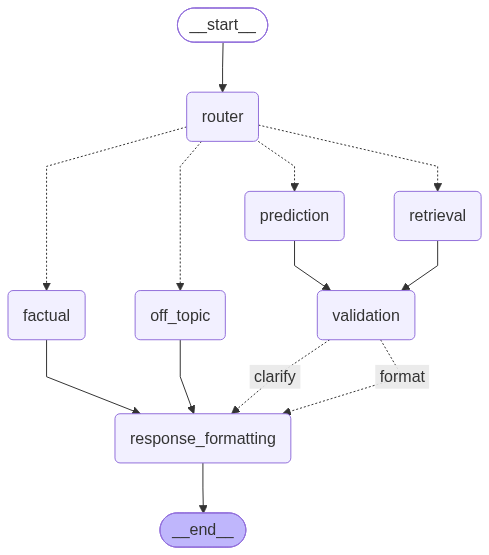

In [210]:
app = graph.compile(checkpointer=memory)
app

In [212]:
png = app.get_graph().draw_mermaid_png()

with open("graph.png", "wb") as f:
    f.write(png)